In [2]:
import pandas as pd

movies = pd.read_csv("data/movies.csv")
users = pd.read_csv("data/users.csv")
ratings = pd.read_csv("data/ratings.csv")

print(movies.head())
print(users.head())
print(ratings.head())

   movie_id         title        genre  release_year  duration_minutes  \
0         1   Center Late       Comedy          1991               174   
1         2    Hope Crime       Sci-Fi          1998               174   
2         3   Stuff Maybe  Documentary          1995               155   
3         4    Wife Peace       Action          1995               107   
4         5  Month Strong       Action          2002               171   

   avg_rating  
0         3.2  
1         2.8  
2         3.6  
3         3.1  
4         4.1  
   user_id  age  country subscription_type
0        1   34    India           Premium
1        2   34      USA             Basic
2        3   56   Canada          Standard
3        4   64       UK          Standard
4        5   56  Germany             Basic
   user_id  movie_id  rating  watch_date
0       22        41       5  2026-03-04
1        9        20       2  2025-04-28
2       45        20       2  2026-03-21
3       27        53       3  2024-11

In [3]:
print(movies.shape)
print(users.shape)
print(ratings.shape)

(100, 6)
(50, 4)
(1000, 4)


In [4]:
print(movies.isnull().sum())
print(users.isnull().sum())
print(ratings.isnull().sum())

movie_id            0
title               0
genre               0
release_year        0
duration_minutes    0
avg_rating          0
dtype: int64
user_id              0
age                  0
country              0
subscription_type    0
dtype: int64
user_id       0
movie_id      0
rating        0
watch_date    0
dtype: int64


In [5]:
print(ratings["rating"].value_counts().sort_index())

rating
1    201
2    191
3    219
4    197
5    192
Name: count, dtype: int64


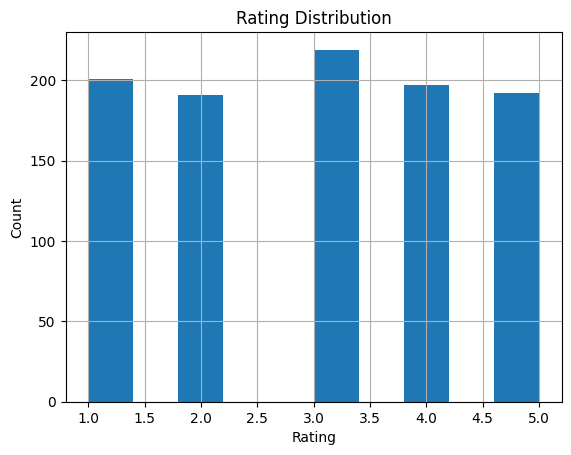

In [6]:
import matplotlib.pyplot as plt

ratings["rating"].hist()
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Rating Distribution")
plt.show()

In [7]:
user_movie_matrix = ratings.pivot_table(
    index="user_id",
    columns="movie_id",
    values="rating"
)

print(user_movie_matrix.shape)
user_movie_matrix.head()

(50, 100)


movie_id,1,2,3,4,5,6,7,8,9,10,...,91,92,93,94,95,96,97,98,99,100
user_id,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.5,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,5.0,NaN,NaN,3.0,NaN,3.0
3,NaN,3.0,NaN,NaN,NaN,NaN,NaN,4.0,NaN,1.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
5,NaN,3.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
sparsity = (
    user_movie_matrix.isna().sum().sum()
    / (user_movie_matrix.shape[0] * user_movie_matrix.shape[1])
)

print(f"Sparsity: {sparsity:.2%}")

Sparsity: 81.92%


In [9]:
movie_popularity = (
    ratings.groupby("movie_id")
    .size()
    .reset_index(name="rating_count")
)

popular_movies = (
    movie_popularity
    .merge(movies, on="movie_id")
    .sort_values("rating_count", ascending=False)
)

print(popular_movies.head(10))

    movie_id  rating_count            title      genre  release_year  \
98        99            17   Garden Mention   Thriller          2012   
86        87            17   Recognize That     Comedy          1999   
47        48            17        Real Four     Action          2011   
40        41            17      Since Break  Animation          2000   
81        82            16     Degree Those   Thriller          2022   
56        57            16    Parent Doctor     Comedy          2018   
43        44            14    Box Statement    Romance          2018   
72        73            14       Wrong Ball     Comedy          1990   
31        32            14  Specific Weight      Drama          2019   
11        12            14        Rock More    Fantasy          1995   

    duration_minutes  avg_rating  
98               162         3.8  
86               149         2.6  
47                89         3.8  
40               113         3.8  
81               142         3.1

Popularity-based recommender

In [11]:
import pandas as pd

movies = pd.read_csv("data/movies.csv")
users = pd.read_csv("data/users.csv")
ratings = pd.read_csv("data/ratings.csv")

In [12]:
movie_stats = (
    ratings.groupby("movie_id")
    .agg(
        rating_count=("rating", "count"),
        avg_user_rating=("rating", "mean")
    )
    .reset_index()
)

movie_stats = movie_stats.merge(movies, on="movie_id", how="left")

movie_stats.head()

,movie_id,rating_count,avg_user_rating,title,genre,release_year,duration_minutes,avg_rating
0,1,10,3.600000,Center Late,Comedy,1991,174,3.2
1,2,12,2.916667,Hope Crime,Sci-Fi,1998,174,2.8
2,3,8,3.625000,Stuff Maybe,Documentary,1995,155,3.6
3,4,7,2.571429,Wife Peace,Action,1995,107,3.1
4,5,6,3.500000,Month Strong,Action,2002,171,4.1


In [13]:
def recommend_popular_movies(top_n=10, min_ratings=5):
    recommendations = (
        movie_stats[movie_stats["rating_count"] >= min_ratings]
        .sort_values(
            by=["avg_user_rating", "rating_count"],
            ascending=False
        )
        .head(top_n)
    )

    return recommendations[
        [
            "movie_id",
            "title",
            "genre",
            "release_year",
            "rating_count",
            "avg_user_rating"
        ]
    ]

In [14]:
recommend_popular_movies(top_n=10, min_ratings=5)

,movie_id,title,genre,release_year,rating_count,avg_user_rating
21,22,Type Great,Romance,2003,9,4.000000
51,52,Test Pass,Fantasy,2012,7,4.000000
16,17,Network Option,Thriller,1994,10,3.900000
87,88,Less Take,Romance,1999,8,3.875000
43,44,Box Statement,Romance,2018,14,3.857143
25,26,Buy Trip,Drama,2022,9,3.777778
48,49,Create Around,Thriller,2021,8,3.750000
63,64,Star Feel,Sci-Fi,1993,8,3.750000
2,3,Stuff Maybe,Documentary,1995,8,3.625000
0,1,Center Late,Comedy,1991,10,3.600000


In [15]:
def recommend_popular_by_genre(genre, top_n=10, min_ratings=3):
    recommendations = (
        movie_stats[
            (movie_stats["genre"].str.lower() == genre.lower()) &
            (movie_stats["rating_count"] >= min_ratings)
        ]
        .sort_values(
            by=["avg_user_rating", "rating_count"],
            ascending=False
        )
        .head(top_n)
    )

    return recommendations[
        [
            "movie_id",
            "title",
            "genre",
            "release_year",
            "rating_count",
            "avg_user_rating"
        ]
    ]


In [16]:
recommend_popular_by_genre("Action", top_n=5)

,movie_id,title,genre,release_year,rating_count,avg_user_rating
64,65,Produce Project,Action,2010,12,3.583333
4,5,Month Strong,Action,2002,6,3.500000
92,93,Short Finish,Action,2001,10,3.000000
26,27,Approach Blood,Action,1997,7,2.857143
82,83,Life Natural,Action,1995,13,2.846154


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

movies["content"] = (
    movies["title"].fillna("") + " " +
    movies["genre"].fillna("") + " " +
    movies["release_year"].astype(str)
)

tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(movies["content"])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [18]:
def recommend_similar_movies(title, top_n=5):
    title = title.lower()

    matches = movies[movies["title"].str.lower().str.contains(title)]

    if matches.empty:
        return "Movie not found."

    movie_idx = matches.index[0]

    similarity_scores = list(enumerate(cosine_sim[movie_idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similar_indices = [
        i for i, score in similarity_scores[1:top_n + 1]
    ]

    return movies.loc[
        similar_indices,
        ["movie_id", "title", "genre", "release_year", "avg_rating"]
    ]

In [19]:
movies[["title", "genre"]].head(10)

,title,genre
0,Center Late,Comedy
1,Hope Crime,Sci-Fi
2,Stuff Maybe,Documentary
3,Wife Peace,Action
4,Month Strong,Action
5,Mr Use,Documentary
6,Blood Body,Thriller
7,Attention Administration,Fantasy
8,Call Two,Romance
9,Perhaps Add,Romance


In [21]:
recommend_similar_movies("Center Late", top_n=5)

,movie_id,title,genre,release_year,avg_rating
36,37,Some Interest,Animation,1991,4.8
73,74,If All,Comedy,1994,3.0
67,68,Simple But,Comedy,2005,2.8
79,80,Conference Up,Comedy,1999,3.2
86,87,Recognize That,Comedy,1999,2.6


User ID → recommend movies based on similar users/items

In [22]:
from sklearn.metrics.pairwise import cosine_similarity

user_movie_matrix = ratings.pivot_table(
    index="user_id",
    columns="movie_id",
    values="rating"
).fillna(0)

movie_similarity = cosine_similarity(user_movie_matrix.T)

movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=user_movie_matrix.columns,
    columns=user_movie_matrix.columns
)

In [23]:
def recommend_similar_movies_cf(movie_id, top_n=5):
    similar_scores = movie_similarity_df[movie_id].sort_values(ascending=False)

    similar_movie_ids = similar_scores.iloc[1:top_n + 1].index

    return movies[movies["movie_id"].isin(similar_movie_ids)][
        ["movie_id", "title", "genre", "release_year", "avg_rating"]
    ]

In [24]:
recommend_similar_movies_cf(movie_id=1, top_n=5)

,movie_id,title,genre,release_year,avg_rating
27,28,Without Enter,Fantasy,1994,3.5
56,57,Parent Doctor,Comedy,2018,2.7
59,60,People Off,Sci-Fi,2015,2.9
82,83,Life Natural,Action,1995,3.6
93,94,Onto Play,Fantasy,2005,2.9


In [25]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

user_movie_matrix = ratings.pivot_table(
    index="user_id",
    columns="movie_id",
    values="rating"
).fillna(0)

movie_similarity = cosine_similarity(user_movie_matrix.T)

movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=user_movie_matrix.columns,
    columns=user_movie_matrix.columns
)

In [26]:
def recommend_similar_movies_cf(movie_id, top_n=5):
    similar_scores = movie_similarity_df[movie_id].sort_values(ascending=False)
    similar_movie_ids = similar_scores.iloc[1:top_n + 1].index

    return movies[movies["movie_id"].isin(similar_movie_ids)][
        ["movie_id", "title", "genre", "release_year", "avg_rating"]
    ]

In [27]:
recommend_similar_movies_cf(movie_id=1, top_n=5)

,movie_id,title,genre,release_year,avg_rating
27,28,Without Enter,Fantasy,1994,3.5
56,57,Parent Doctor,Comedy,2018,2.7
59,60,People Off,Sci-Fi,2015,2.9
82,83,Life Natural,Action,1995,3.6
93,94,Onto Play,Fantasy,2005,2.9


User ID → recommend movies the user has not watched yet

In [28]:
def recommend_for_user(user_id, top_n=10):
    if user_id not in user_movie_matrix.index:
        return "User not found."

    user_ratings = user_movie_matrix.loc[user_id]

    watched_movies = user_ratings[user_ratings > 0].index.tolist()

    scores = {}

    for movie_id in watched_movies:
        rating = user_ratings[movie_id]
        similar_movies = movie_similarity_df[movie_id]

        for similar_movie_id, similarity_score in similar_movies.items():
            if similar_movie_id in watched_movies:
                continue

            scores[similar_movie_id] = scores.get(similar_movie_id, 0) + similarity_score * rating

    recommended_movie_ids = (
        pd.Series(scores)
        .sort_values(ascending=False)
        .head(top_n)
        .index
        .tolist()
    )

    return movies[movies["movie_id"].isin(recommended_movie_ids)][
        ["movie_id", "title", "genre", "release_year", "avg_rating"]
    ]

In [29]:
recommend_for_user(user_id=1, top_n=10)

,movie_id,title,genre,release_year,avg_rating
0,1,Center Late,Comedy,1991,3.2
11,12,Rock More,Fantasy,1995,3.2
13,14,Cause Hour,Sci-Fi,2008,4.6
22,23,First Think,Animation,1999,2.8
39,40,Collection Rise,Comedy,2024,2.8
80,81,With Behind,Sci-Fi,2011,4.2
82,83,Life Natural,Action,1995,3.6
84,85,Full Represent,Drama,2006,4.4
97,98,Old Such,Fantasy,2011,4.7
99,100,Really To,Documentary,2011,2.8


Combine content-based + collaborative filtering scores

In [31]:
def hybrid_recommend(user_id, movie_title, top_n=10, content_weight=0.5, cf_weight=0.5):
    title = movie_title.lower()

    matches = movies[movies["title"].str.lower().str.contains(title)]

    if matches.empty:
        return "Movie not found."

    if user_id not in user_movie_matrix.index:
        return "User not found."

    movie_idx = matches.index[0]
    movie_id = movies.loc[movie_idx, "movie_id"]

    # Content-based similarity scores
    content_scores = pd.Series(
        cosine_sim[movie_idx],
        index=movies["movie_id"]
    )

    # Collaborative filtering similarity scores
    cf_scores = movie_similarity_df[movie_id]

    user_ratings = user_movie_matrix.loc[user_id]
    watched_movies = user_ratings[user_ratings > 0].index.tolist()

    combined_scores = (
        content_weight * content_scores +
        cf_weight * cf_scores
    )

    combined_scores = combined_scores.drop(labels=watched_movies, errors="ignore")

    recommended_ids = combined_scores.sort_values(ascending=False).head(top_n).index

    return movies[movies["movie_id"].isin(recommended_ids)][
        ["movie_id", "title", "genre", "release_year", "avg_rating"]
    ]

In [33]:
hybrid_recommend(user_id=1, movie_title="Collection Rise", top_n=10)

,movie_id,title,genre,release_year,avg_rating
0,1,Center Late,Comedy,1991,3.2
39,40,Collection Rise,Comedy,2024,2.8
58,59,Such Voice,Sci-Fi,2000,3.7
67,68,Simple But,Comedy,2005,2.8
79,80,Conference Up,Comedy,1999,3.2
80,81,With Behind,Sci-Fi,2011,4.2
89,90,Or Mind,Sci-Fi,2005,2.8
94,95,Already Drug,Comedy,2014,4.6
97,98,Old Such,Fantasy,2011,4.7
99,100,Really To,Documentary,2011,2.8


Phase 7

In [34]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [35]:
train_ratings, test_ratings = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42
)

print("Train ratings:", train_ratings.shape)
print("Test ratings:", test_ratings.shape)

Train ratings: (800, 4)
Test ratings: (200, 4)


In [36]:
train_user_movie_matrix = train_ratings.pivot_table(
    index="user_id",
    columns="movie_id",
    values="rating"
).fillna(0)

train_movie_similarity = cosine_similarity(train_user_movie_matrix.T)

train_movie_similarity_df = pd.DataFrame(
    train_movie_similarity,
    index=train_user_movie_matrix.columns,
    columns=train_user_movie_matrix.columns
)

In [37]:
def recommend_for_user_train(user_id, top_n=10):
    if user_id not in train_user_movie_matrix.index:
        return []

    user_ratings = train_user_movie_matrix.loc[user_id]
    watched_movies = user_ratings[user_ratings > 0].index.tolist()

    scores = {}

    for movie_id in watched_movies:
        rating = user_ratings[movie_id]

        if movie_id not in train_movie_similarity_df.columns:
            continue

        similar_movies = train_movie_similarity_df[movie_id]

        for similar_movie_id, similarity_score in similar_movies.items():
            if similar_movie_id in watched_movies:
                continue

            scores[similar_movie_id] = scores.get(similar_movie_id, 0) + similarity_score * rating

    if not scores:
        return []

    recommended_movie_ids = (
        pd.Series(scores)
        .sort_values(ascending=False)
        .head(top_n)
        .index
        .tolist()
    )

    return recommended_movie_ids

Precision

In [38]:
def precision_at_k(recommended, actual, k=10):
    recommended_at_k = recommended[:k]

    if len(recommended_at_k) == 0:
        return 0

    hits = len(set(recommended_at_k) & set(actual))

    return hits / k

Recall@K

In [39]:
def recall_at_k(recommended, actual, k=10):
    recommended_at_k = recommended[:k]

    if len(actual) == 0:
        return 0

    hits = len(set(recommended_at_k) & set(actual))

    return hits / len(actual)

In [40]:
def evaluate_recommender(k=10, rating_threshold=4):
    precision_scores = []
    recall_scores = []

    test_relevant = (
        test_ratings[test_ratings["rating"] >= rating_threshold]
        .groupby("user_id")["movie_id"]
        .apply(list)
        .to_dict()
    )

    for user_id, actual_movies in test_relevant.items():
        recommended_movies = recommend_for_user_train(user_id, top_n=k)

        precision_scores.append(
            precision_at_k(recommended_movies, actual_movies, k)
        )

        recall_scores.append(
            recall_at_k(recommended_movies, actual_movies, k)
        )

    return {
        "Precision@K": np.mean(precision_scores),
        "Recall@K": np.mean(recall_scores),
        "Users Evaluated": len(test_relevant)
    }

In [41]:
evaluate_recommender(k=10, rating_threshold=4)

{'Precision@K': np.float64(0.01842105263157895),
 'Recall@K': np.float64(0.08771929824561403),
 'Users Evaluated': 38}

In [43]:
for k in [5, 10, 20]:
    print(k, evaluate_recommender(k=k, rating_threshold=4))

5 {'Precision@K': np.float64(0.021052631578947368), 'Recall@K': np.float64(0.061403508771929814), 'Users Evaluated': 38}
10 {'Precision@K': np.float64(0.01842105263157895), 'Recall@K': np.float64(0.08771929824561403), 'Users Evaluated': 38}
20 {'Precision@K': np.float64(0.01842105263157895), 'Recall@K': np.float64(0.1557017543859649), 'Users Evaluated': 38}


In [44]:
evaluate_recommender(k=10, rating_threshold=3)

{'Precision@K': np.float64(0.02727272727272728),
 'Recall@K': np.float64(0.09377705627705626),
 'Users Evaluated': 44}